In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('house_price_univariate_dataset.csv')
df

,Area (sqft),Price
0,500.00,799671.42
1,504.50,742930.33
2,509.01,828282.37
3,513.51,922573.26
4,518.02,753611.69
...,...,...
995,4981.98,7444862.94
996,4986.49,7659498.38
997,4990.99,7550570.77
998,4995.50,7436125.34


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area (sqft)  1000 non-null   float64
 1   Price        1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [5]:
df.describe()

,Area (sqft),Price
count,1000.00000,1.000000e+03
mean,2750.00000,4.126933e+06
std,1300.98845,1.957405e+06
min,500.00000,6.465098e+05
25%,1625.00250,2.424579e+06
50%,2750.00000,4.115129e+06
75%,3874.99750,5.810007e+06
max,5000.00000,7.659498e+06


In [6]:
df.columns

Index(['Area (sqft)', 'Price'], dtype='object')

In [7]:
x=df[['Area (sqft)']]
y=df[['Price']]
x

,Area (sqft)
0,500.00
1,504.50
2,509.01
3,513.51
4,518.02
...,...
995,4981.98
996,4986.49
997,4990.99
998,4995.50


In [8]:
y

,Price
0,799671.42
1,742930.33
2,828282.37
3,922573.26
4,753611.69
...,...
995,7444862.94
996,7659498.38
997,7550570.77
998,7436125.34


In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)
x_train

,Area (sqft)
791,4063.06
143,1144.14
880,4463.96
339,2027.03
992,4968.47
...,...
544,2950.45
892,4518.02
643,3396.40
414,2364.86


In [10]:
x_test

,Area (sqft)
726,3770.27
243,1594.59
342,2040.54
976,4896.40
919,4639.64
...,...
458,2563.06
169,1261.26
297,1837.84
10,545.05


In [11]:
y_train

,Price
791,6115363.36
143,1734679.60
880,6948639.19
339,2984168.09
992,7427984.96
...,...
544,4178511.23
892,6883694.50
643,4944280.30
414,3580528.70


In [12]:
y_test

,Price
726,5657248.80
243,2478467.41
342,3085307.47
976,7299363.96
919,6978868.46
...,...
458,3789229.66
169,1816518.28
297,2787486.71
10,771225.80


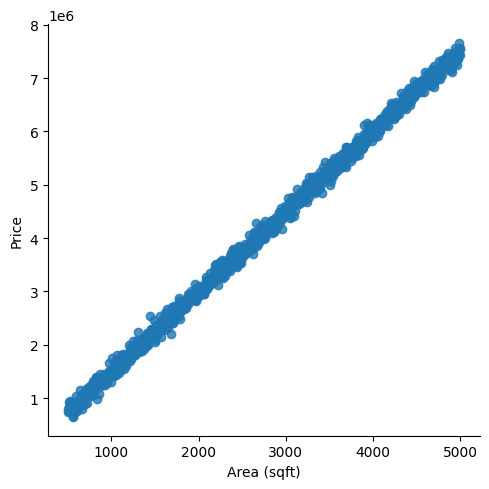

In [13]:
sns.lmplot(x='Area (sqft)',y='Price',data=df)

In [14]:
from sklearn.linear_model import LinearRegression
le=LinearRegression()
le.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
le.coef_

array([[1502.66293459]])

In [16]:
le.intercept_

array([-5116.17270441])

In [17]:
ypred=le.predict(x_test)
ypred

array([[5660328.80969822],
       [2391015.11616599],
       [3061127.65184711],
       [7352522.62022985],
       [6966698.88514411],
       [5200048.12620347],
       [2485788.06745068],
       [5037610.26297412],
       [ 969586.13981842],
       [6986999.86139044],
       [2986670.7034381 ],
       [4029052.95453494],
       [2167659.2975683 ],
       [4374259.71049866],
       [5748324.7511479 ],
       [1098184.03376077],
       [3941072.0397146 ],
       [3426635.38405717],
       [3027287.68256011],
       [6222129.40105398],
       [6479355.24219737],
       [3277721.48723914],
       [5904000.63117159],
       [3480791.35621985],
       [5836320.69259759],
       [5193286.14299781],
       [4225360.84030998],
       [4624708.54180704],
       [3900455.06059259],
       [3934295.02987959],
       [4956376.3047301 ],
       [2242116.24597731],
       [1253874.94041381],
       [6174750.4387263 ],
       [2648240.95730938],
       [6871940.96048876],
       [2330097.16079765],
 

In [18]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
y_true = y_test.values.ravel()
y_pred = ypred.ravel()

print(mean_absolute_error(y_true, y_pred))
print(mean_squared_error(y_true, y_pred))
print(r2_score(y_true, y_pred))


80363.4885590516
9981084826.954433
0.997296785157041


In [19]:
result = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': ypred.flatten()
})
result = result.reset_index(drop=True)

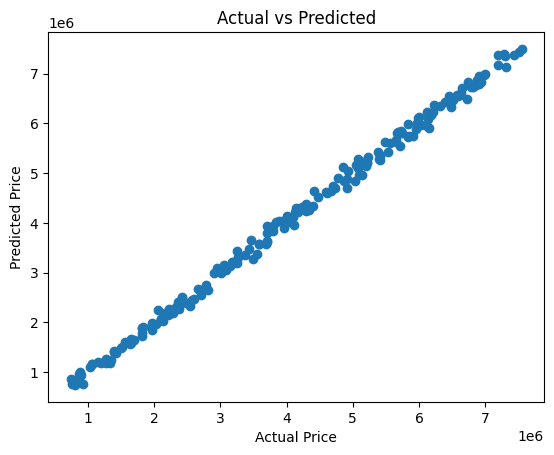

In [20]:
plt.scatter(y_test, ypred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


In [21]:
print(r2_score(y_test,ypred))

0.997296785157041


In [24]:
residual=y_test-ypred
residual

,Price
726,-3080.009698
243,87452.293834
342,24179.818153
976,-53158.660230
919,12169.574856
...,...
458,-57069.428430
169,-73614.200179
297,30948.834995
10,-42684.459795


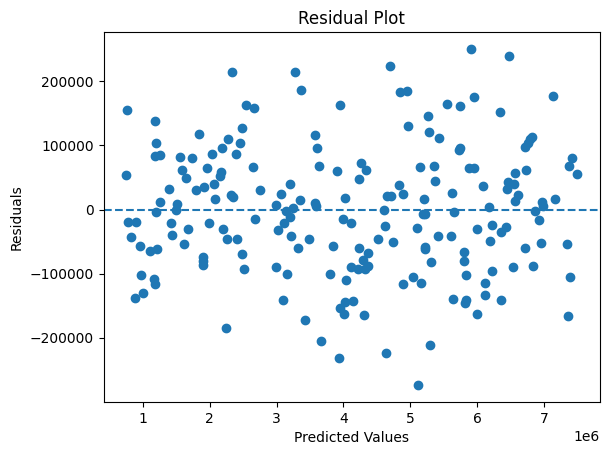

In [25]:
plt.scatter(y_pred, residual)
plt.axhline(y=0, linestyle='--')  # horizontal line at 0
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()